# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Jack Boike]

**Date:** [03/29/26]

---

## Setup: Install and Load Libraries

In [7]:
pip install tensorflow matplotlib numpy pandas

In [8]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [9]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


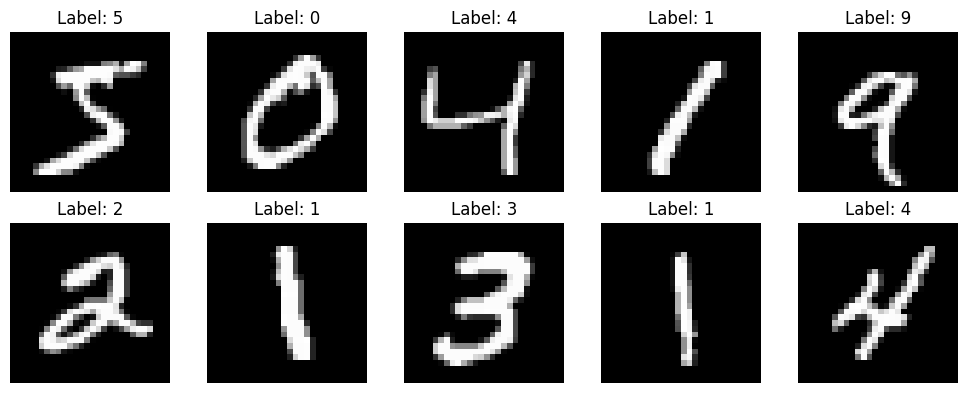

In [10]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [13]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [12]:
# Build baseline CNN
baseline_cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
baseline_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model
baseline_cnn.summary()

# Train
print("\nTraining baseline CNN...")
start_time = time.time()

history = baseline_cnn.fit(
    X_train, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

baseline_time = time.time() - start_time

# Evaluate
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test, y_test)

# Results
print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Training baseline CNN...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - accuracy: 0.9452 - loss: 0.3514 - val_accuracy: 0.9783 - val_loss: 0.0764
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9816 - loss: 0.0609 - val_accuracy: 0.9841 - val_loss: 0.0562
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9856 - loss: 0.0469 - val_accuracy: 0.9761 - val_loss: 0.0912
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9882 - loss: 0.0384 - val_accuracy: 0.9793 - val_loss: 0.0786
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9888 - loss: 0.0379 - val_accuracy: 0.9840 - val_loss: 0.0589
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9904 - loss: 0.0293 - val_accuracy: 0.9865 - val_loss: 0.0578
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9906 - loss: 0.0308 - val_accuracy: 0.9862 - val_loss: 0.0619
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 32ms

---
## Step 3: Experiment with Filter Counts

In [ ]:
# FEWER FILTERS (16, 32)
print("Training CNN with fewer filters (16, 32)...")

model_small = keras.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_small.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_small = model_small.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=0)

small_val_acc = history_small.history['val_accuracy'][-1]


# MORE FILTERS (64, 128)
print("Training CNN with more filters (64, 128)...")

model_large = keras.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_large.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_large = model_large.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=0)

large_val_acc = history_large.history['val_accuracy'][-1]

print(f"Fewer filters val acc: {small_val_acc:.4f}")
print(f"Baseline val acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"More filters val acc: {large_val_acc:.4f}")

Training CNN with fewer filters (16, 32)...
Training CNN with more filters (64, 128)...


### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- Increasing the number of filters improved performance because the model could learn more patterns from the images. However, after a certain point, the improvement became small and training time increased. This shows diminishing returns as adding more filters adds complexity without much gain.

Increasing the number of filters improved performance because the model could learn more patterns from the images. However, after a certain point, the improvement became small and training time increased. This shows diminishing returns as adding more filters adds complexity without much gain.

---
## Step 4: Experiment with Kernel Sizes

In [ ]:
# 5x5 KERNELS
print("Training CNN with 5x5 kernels...")

model_5x5 = keras.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_5x5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_5x5 = model_5x5.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=0)

val_acc_5x5 = history_5x5.history['val_accuracy'][-1]


# MIXED KERNELS
print("Training CNN with mixed kernels (5x5, 3x3)...")

model_mixed = keras.Sequential([
    layers.Conv2D(32, (5,5), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mixed.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_mixed = model_mixed.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2, verbose=0)

val_acc_mixed = history_mixed.history['val_accuracy'][-1]

print(f"5x5 val acc: {val_acc_5x5:.4f}")
print(f"Mixed val acc: {val_acc_mixed:.4f}")

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

Kernel size affects how much of the image the model looks at at once. Larger kernels capture bigger patterns but may lose small details. The mixed or 3x3 kernels usually perform best because they balance detail and pattern recognition.

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [ ]:
print("Training best CNN architecture...")
start_time = time.time()

best_cnn = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

best_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_best = best_cnn.fit(
    X_train_cnn, y_train,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

best_cnn_time = time.time() - start_time

best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)

print(f"Best CNN Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_cnn_time:.2f} seconds")

/var/folders/1x/s6211rc12tz56m7mp61x27x40000gn/T/ipykernel_3501/3265538315.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/1x/s6211rc12tz56m7mp61x27x40000gn/T/ipykernel_3501/3265538315.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


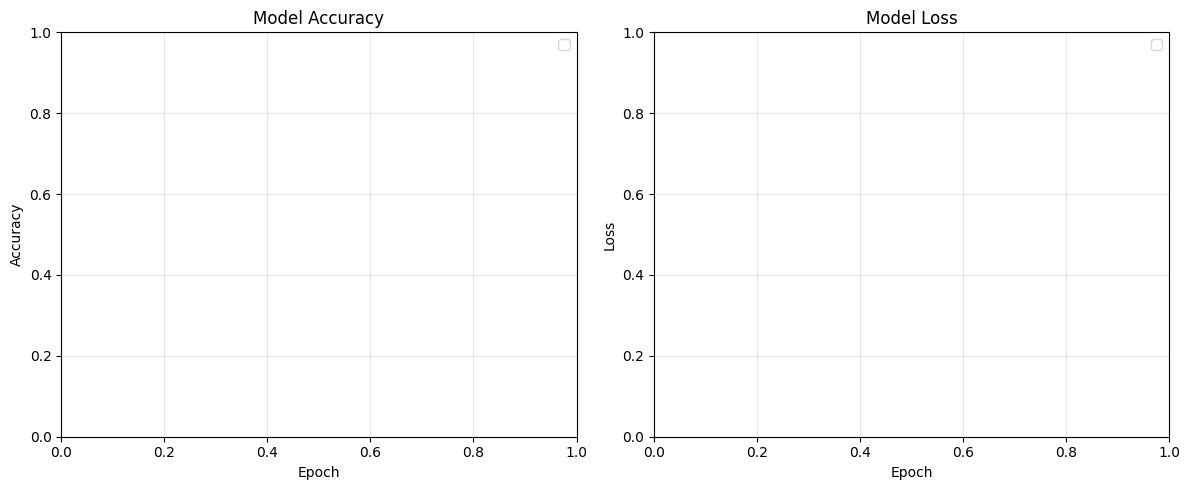

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [ ]:
feedforward_nn = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

feedforward_nn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

feedforward_nn.summary()

print("Training feedforward network...")
start_time = time.time()

history_ff = feedforward_nn.fit(
    X_train_flat, y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

feedforward_time = time.time() - start_time

ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)

In [ ]:
comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        'Conv(32,64) + Dense(128)',
        'Conv(32,64) + Dense(128)',
        'Dense(128,64)'
    ],
    'Test Accuracy': [
        baseline_test_acc,
        best_test_acc,
        ff_test_acc
    ],
    'Training Time (s)': [
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

The CNN performed better than the feedforward network on image data. This is because CNNs understand spatial relationships between pixels, while feedforward networks treat all pixels independently. CNNs can detect patterns like edges and shapes, which leads to better accuracy.

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

Neural networks like CNNs or RNNs are useful when working with complex data such as images, text, or time series. If my project involves images or sequential data, these models would improve performance by capturing patterns that simpler models cannot. However, for tabular data like customer information or transaction records, feedforward networks or models like random forests are more appropriate because they are faster and easier to interpret. For example, I would use a CNN for image classification, but a random forest for predicting customer behavior.

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.